In [1]:
# Import modules:
from beam_manager import open_beam_library, sublibrary
from bridge_manager import Bridge
from myDAQ_manager import logs_to_U

import numpy as np
import matplotlib.pyplot as plt

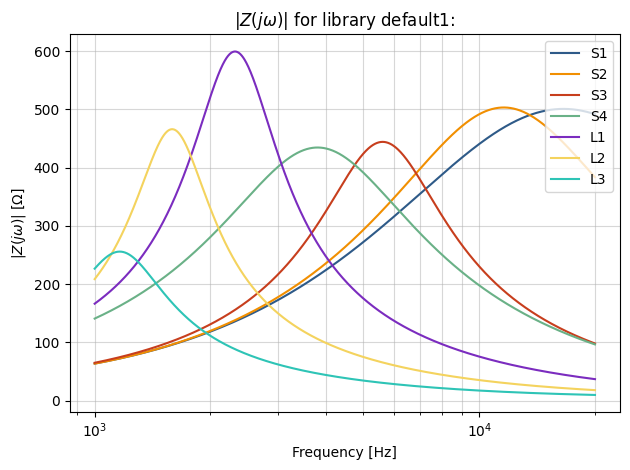

In [2]:
library_name = 'default1'
library = open_beam_library(library_name + '.json')

fig, ax = plt.subplots()
colors = ['#2E5A88', '#F18F01', '#C73E1D', '#6AB187', '#7B2CBF', '#F4D35E', '#2EC4B6']
f_logrange = (3, np.log10(2e4)) # max frequency sweep between 100 and 20 000 Hz (audio range)
f_start, f_stop = f_logrange
f_arr = np.logspace(f_start, f_stop, 2000)

for beam, color in zip(list(library.values()), colors):
    beam.impedance_plot(ax, f_arr, color)

ax.grid(True, which="both", ls="-", alpha=0.5)
ax.set_ylabel(r'$|Z(j\omega)|$ [$\Omega$]')
ax.set_xlabel('Frequency [Hz]')
ax.legend(loc='upper right')

plt.title(fr'$|Z(j\omega)|$ for library {library_name}:')
plt.tight_layout()
plt.show()

Resonance frequencies: Theory: 4992.675, Measurements: 1536.975


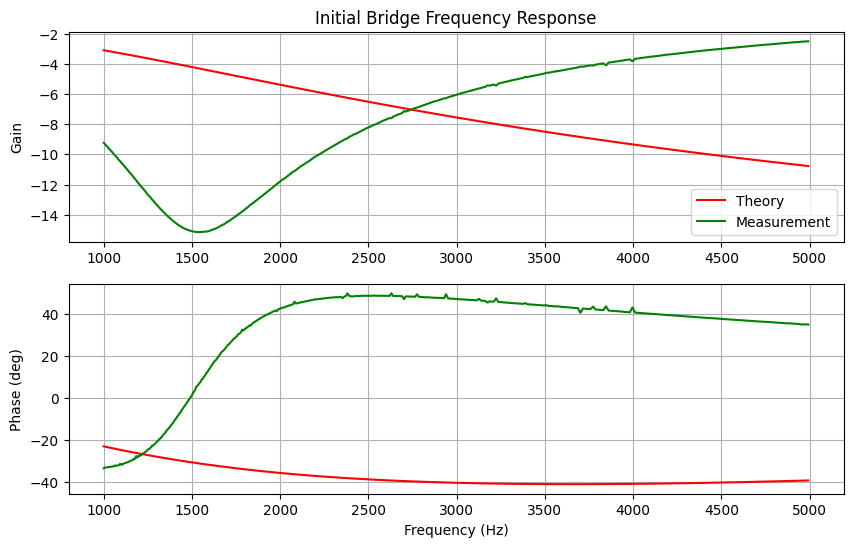

In [3]:
selection = ['S1']
lib = sublibrary(selection, library)

R_ref = 98.66 # Ohm

f_logrange = (2, np.log10(2e4)) # max frequency sweep between 100 and 20 000 Hz (audio range)

topology = [(0, 1)]
struc = Bridge()
struc.construct(lib, topology)


# Measured (initial) beamresponse:
filename = 'L2test3.txt'
f_arr_mes, gain_mes, phase_mes = logs_to_U(filename, Cartesian=False)
_, U_out_mes = logs_to_U(filename, Cartesian=True)

# Theoretical (initial) beam response:
U_initial = struc.initial_response(f_arr_mes, R_ref, plot=False)
gain_theory = np.abs(U_initial)
phase_theory = np.degrees(np.angle(U_initial))

# filename2 = 'jo2.txt'
# f_arr_mes2, gain_mes2, phase_mes2 = logs_to_U(filename2, Cartesian=False)
# _, U_out_mes2 = logs_to_U(filename2, Cartesian=True)

# Theoretical (initial) beam response:
# U_initial2 = struc.initial_response(f_arr_mes2, R_ref, plot=False)
# gain_theory2 = np.abs(U_initial)
# phase_theory2 = np.degrees(np.angle(U_initial))

# Plot to compare:
plt.figure(figsize=(10, 6))

# Plot Magnitude
plt.subplot(2, 1, 1)
plt.plot(f_arr_mes, 20*np.log10(gain_theory), color='r', label='Theory')
plt.plot(f_arr_mes, 20*np.log10(gain_mes), color='g', label='Measurement')
# plt.plot(f_arr_mes2, gain_mes2, color='y', label='Measurement2')
plt.ylabel('Gain')
plt.grid(True, which="both")
plt.legend()
plt.title('Initial Bridge Frequency Response')


# Plot Phase:
plt.subplot(2, 1, 2)
plt.plot(f_arr_mes, phase_theory, color='r', label='Theory')
plt.plot(f_arr_mes, phase_mes, color='g', label='Measurement')
# plt.plot(f_arr_mes2, phase_mes2, color='y', label='Measurement2')
plt.ylabel('Phase (deg)')
plt.xlabel('Frequency (Hz)')
plt.grid(True, which="both", ls="-")

f_res_theory = f_arr_mes[np.argmin(gain_theory)]
f_res_mes = f_arr_mes[np.argmin(gain_mes)]

print(f'Resonance frequencies: Theory: {f_res_theory}, Measurements: {f_res_mes}')



In [4]:
R_def = [800] # Initial resistance for our build filter!

R_pred = struc.sweep(R_ref, f_logrange=(3, np.log10(1e4)), freqsteps=30, myDAQ=True, myDAQlog=None, save_filename='result.txt',  resonance_sweep=False, geo_constraint=False, position_plot=False, error_plot=True, response_comparison_plot=True, )


print(f'The correct R values were {R_def}, and the solver predicted {R_pred}.')

myDAQsweep started...


com_error: (-2147352567, 'Er is een uitzondering opgetreden.', (6945, 'LabVIEW', 'LabVIEW: (Hex 0x5A5) Open VI Reference no longer matches VIs in memory by filename. A filename is no longer sufficient because the full name of a VI now includes any owning libraries.', None, 0, 0), None)

In [ ]:
import copy
from scipy.optimize import minimize, differential_evolution
import numpy as np
import matplotlib.pyplot as plt

def library_calibration(calib_library, R_ref, plot=True):
    results = {}

    for beam_id, data in calib_library.items():
        measurements = data.get('measurements', [])
        if not measurements: continue
        
        orig_beam = data['beam']

        # Vaste parameters uit library:
        L_fixed       = orig_beam.L
        R_coil_fixed  = orig_beam.R_coil
        R_contact_fixed = orig_beam.R_contact
        C_start       = orig_beam.C[0] if isinstance(orig_beam.C, list) else orig_beam.C
        R_cap_start   = orig_beam.R_cap

        # Dipfrequentie bepalen uit eerste meting
        U_first = measurements[0]['U_out_mes']
        f_first = measurements[0]['f_arr']
        idx_dip = np.argmin(np.abs(U_first))
        f_dip   = f_first[idx_dip]
        w_dip   = 2 * np.pi * f_dip
        LC_fixed = 1 / w_dip**2  # f_res blijft exact

        print(f"Kalibreren {beam_id}...")
        print(f"  f_dip    = {f_dip:.1f} Hz")
        print(f"  L_fixed  = {L_fixed:.4e} H")
        print(f"  R_coil   = {R_coil_fixed:.2f} Ω (vast)")
        print(f"  R_contact= {R_contact_fixed:.2f} Ω (vast)")

        def cost(params):
            C, R_cap = params
            L = LC_fixed / C  # f_res altijd exact

            test_beam = copy.deepcopy(orig_beam)
            test_beam.L       = L
            test_beam.C       = [C]
            test_beam.R_cap   = R_cap
            # Alle andere parameters vast:
            test_beam.R_coil    = R_coil_fixed
            test_beam.R_contact = R_contact_fixed
            

            temp_struc = Bridge()
            temp_struc.construct({beam_id: test_beam}, [(0, 1)])

            total_err = 0
            for m in measurements:
                U_pred = temp_struc.solve_U(m['f_arr'], R_ref)
                total_err += np.mean(np.abs(m['U_out_mes'] - U_pred)**2)

            return np.sqrt(total_err / len(measurements))

        bounds = [
            (C_start/20, C_start*20),  # C
            (0.1, 100),                 # R_cap
        ]

        # Meerdere startpunten
        x0_list = [
            [C_start,     R_cap_start],
            [C_start*5,   R_cap_start],
            [C_start*10,  R_cap_start*2],
            [C_start/5,   R_cap_start],
            [C_start*20,  R_cap_start*3],
        ]

        best_cost = np.inf
        best_x    = None

        print("  Startpunten proberen...")
        for x0 in x0_list:
            x0_clipped = [np.clip(x0[i], bounds[i][0], bounds[i][1]) for i in range(2)]
            res = minimize(cost, x0_clipped, method='SLSQP', bounds=bounds,
                          options={'ftol': 1e-12, 'maxiter': 1000})
            if res.fun < best_cost:
                best_cost = res.fun
                best_x    = res.x
                L_test = LC_fixed / res.x[0]
                print(f"    Beter: cost={res.fun:.6f}, C={res.x[0]:.2e}, "
                      f"R_cap={res.x[1]:.2f}, L={L_test:.4e}")

        print("  Globale optimalisatie...")
        res_global = differential_evolution(
            cost, bounds, maxiter=1000, tol=1e-12, seed=42,
            workers=1, popsize=20, x0=[best_x]
        )

        print("  Lokale verfijning...")
        res_final = minimize(cost, res_global.x, method='SLSQP', bounds=bounds,
                            options={'ftol': 1e-12, 'maxiter': 1000})

        C_pred   = res_final.x[0]
        Rcap_pred = res_final.x[1]
        L_pred   = LC_fixed / C_pred
        f_res    = 1 / (2*np.pi*np.sqrt(L_pred * C_pred))

        results[beam_id] = {
            'L': L_pred, 'C': [C_pred],
            'R_cap': Rcap_pred,
            # Ongewijzigd:
            'R_coil': R_coil_fixed,
            'R_contact': R_contact_fixed,
        }

        print(f"\n  Resultaat {beam_id}:")
        print(f"  L       = {L_pred:.6e} H  (was {L_fixed:.6e})")
        print(f"  C       = {C_pred:.6e} F  (was {C_start:.6e})")
        print(f"  R_cap   = {Rcap_pred:.2f} Ω  (was {R_cap_start:.2f})")
        print(f"  R_coil  = {R_coil_fixed:.2f} Ω  (vast)")
        print(f"  f_res   = {f_res:.1f} Hz  (target {f_dip:.1f} Hz)")
        print(f"  RMSE    = {res_final.fun:.6f}")

        if plot:
            # Update tijdelijke beam voor plot
            plot_beam = copy.deepcopy(orig_beam)
            plot_beam.L       = L_pred
            plot_beam.C       = [C_pred]
            plot_beam.R_cap   = Rcap_pred
            plot_beam.R_coil  = R_coil_fixed
            plot_beam.R_contact = R_contact_fixed

            temp_struc = Bridge()
            temp_struc.construct({beam_id: plot_beam}, [(0, 1)])

            f    = measurements[0]['f_arr']
            U_m  = measurements[0]['U_out_mes']
            U_p  = temp_struc.solve_U(f, R_ref)

            fig, axs = plt.subplots(2, 1, figsize=(10, 8))

            axs[0].semilogx(f, np.abs(U_m), color='blue', label='Meting')
            axs[0].semilogx(f, np.abs(U_p), color='orange', linestyle='--', label='Fit')
            axs[0].axvline(f_dip, color='red', linestyle=':', alpha=0.5,
                          label=f'f_dip={f_dip:.0f} Hz')
            axs[0].set_ylabel(r'$|U_{out}|$ (V)')
            axs[0].grid(True, which='both')
            axs[0].legend()
            axs[0].set_title(f'{beam_id}: L={L_pred:.3e}, C={C_pred:.2e}, '
                            f'R_cap={Rcap_pred:.1f} Ω, R_coil={R_coil_fixed:.1f} Ω')

            axs[1].semilogx(f, np.degrees(np.angle(U_m)), color='blue', label='Meting')
            axs[1].semilogx(f, np.degrees(np.angle(U_p)), color='orange',
                           linestyle='--', label='Fit')
            axs[1].axvline(f_dip, color='red', linestyle=':', alpha=0.5)
            axs[1].set_ylabel('Fase (deg)')
            axs[1].set_xlabel('Frequentie (Hz)')
            axs[1].grid(True, which='both')
            axs[1].legend()

            plt.tight_layout()
            plt.show()

    return results


# Gebruik:
calib_library = {
    'A1': {
        'beam': library['A1'],
        'measurements': [{'f_arr': f_arr_mes, 'U_out_mes': U_out_mes}]
    }
}

results = library_calibration(calib_library, R_ref, plot=True)

# Update library met gekalibreerde waarden
for beam_id, params in results.items():
    beam = library[beam_id]
    beam.L         = params['L']
    beam.C         = params['C']
    beam.R_cap     = params['R_cap']
    # Ongewijzigd:
    beam.R_coil    = params['R_coil']
    beam.R_contact = params['R_contact']


    print(f"\nLibrary update {beam_id}:")
    print(f"  L         = {beam.L:.4e} H")
    print(f"  C         = {beam.C[0]:.4e} F")
    print(f"  R_cap     = {beam.R_cap:.2f} Ω")
    print(f"  R_coil    = {beam.R_coil:.2f} Ω (ongewijzigd)")
    print(f"  R_contact = {beam.R_contact:.2f} Ω (ongewijzigd)")

# Bridge opnieuw bouwen met gekalibreerde library
struc.construct(sublibrary(['A1'], library), topology)

KeyError: 'A1'